In [ ]:
# Copyright 2026 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Chicago Crimes Analysis

### 1) Create a Spark sesssion

In [9]:
from google.cloud.dataproc_spark_connect import DataprocSparkSession
from google.cloud.dataproc_v1 import Session

PROJECT_ID_LIST=!gcloud config list --format "value(core.project)" 2>/dev/null
PROJECT_ID=PROJECT_ID_LIST[0]
LOCATION="us-central1"
PREDEFINED_INTERACTIVE_SESSION_TEMPLATE_NAME = "sparkconnect-service-account-template"

# Configure the serverless managed interactive_session with an existing session template
managed_interactive_session = Session()
managed_interactive_session.session_template = f"projects/{PROJECT_ID}/locations/{LOCATION}/sessionTemplates/{PREDEFINED_INTERACTIVE_SESSION_TEMPLATE_NAME}"

# Create the Spark session.
spark = (
   DataprocSparkSession.builder
     .appName("Chicago Crimes Analysis")
     .dataprocSessionConfig(managed_interactive_session)
     .getOrCreate()
)


███████████████████▋                                                            

In [10]:
spark

### 2) Load data from a public dataset into a dataframe

In [11]:
# Read data from BigQuery
baseDF = spark.read \
  .format('bigquery') \
  .load('bigquery-public-data.chicago_crime.crime')

In [12]:
# Print schema
baseDF.printSchema()

root
 |-- unique_key: long (nullable = false)
 |-- case_number: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- block: string (nullable = true)
 |-- iucr: string (nullable = true)
 |-- primary_type: string (nullable = true)
 |-- description: string (nullable = true)
 |-- location_description: string (nullable = true)
 |-- arrest: boolean (nullable = true)
 |-- domestic: boolean (nullable = true)
 |-- beat: long (nullable = true)
 |-- district: long (nullable = true)
 |-- ward: long (nullable = true)
 |-- community_area: long (nullable = true)
 |-- fbi_code: string (nullable = true)
 |-- x_coordinate: double (nullable = true)
 |-- y_coordinate: double (nullable = true)
 |-- year: long (nullable = true)
 |-- updated_on: timestamp (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- location: string (nullable = true)



In [13]:
display(baseDF.show(3,truncate=False))

  0%|           0/1 Tasks

+----------+-----------+-------------------+------------------+----+-----------------------+--------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+-----------------------------+
|unique_key|case_number|date               |block             |iucr|primary_type           |description   |location_description|arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|updated_on         |latitude    |longitude    |location                     |
+----------+-----------+-------------------+------------------+----+-----------------------+--------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+-----------------------------+
|12799695  |JF363340   |2022-06-11 00:00:00|0000X E WACKER DR |0281|CRIMINAL SEXUAL ASSAULT|NON-AGGRAVATED|SIDEW

None

In [14]:
baseDF.createOrReplaceTempView("chicago_crimes_raw")

### 3) Transform the dataset

#### 3.1. Deduplicate

In [15]:
# 3.1.a. Read raw crimes into a dataframe
rawDF=spark.sql("select * from chicago_crimes_raw")

In [16]:
# 3.1.b. Dedupe the data
dedupedRawDF=rawDF.dropDuplicates()

In [17]:
dedupedRawDF.printSchema()

root
 |-- unique_key: long (nullable = false)
 |-- case_number: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- block: string (nullable = true)
 |-- iucr: string (nullable = true)
 |-- primary_type: string (nullable = true)
 |-- description: string (nullable = true)
 |-- location_description: string (nullable = true)
 |-- arrest: boolean (nullable = true)
 |-- domestic: boolean (nullable = true)
 |-- beat: long (nullable = true)
 |-- district: long (nullable = true)
 |-- ward: long (nullable = true)
 |-- community_area: long (nullable = true)
 |-- fbi_code: string (nullable = true)
 |-- x_coordinate: double (nullable = true)
 |-- y_coordinate: double (nullable = true)
 |-- year: long (nullable = true)
 |-- updated_on: timestamp (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- location: string (nullable = true)



#### 3.2. Augment the data with temporal attributes

In [18]:
# 3.2.a. Create a UDF to return day of the week
from pyspark.sql.types import *
from pyspark.sql.functions import *

def getDayNameFromWeekdayNbr(weekday):
    if weekday == 0:
        return "Monday"
    if weekday == 1:
        return "Tuesday"
    if weekday == 2:
        return "Wednesday"
    if weekday == 3:
        return "Thursday"
    if weekday == 4:
        return "Friday"
    if weekday == 5:
        return "Saturday"
    if weekday == 6:
        return "Sunday"

udf_getDayNameFromWeekdayNbr = udf(getDayNameFromWeekdayNbr, StringType())

In [19]:
# 3.2.b. Add a column case_timestamp with case_dt_tm formatted to timestamp and create a temporary view on this
augmentedDF=spark.sql("select * from chicago_crimes_raw").withColumn("case_timestamp",to_timestamp("date","MM/dd/yyyy hh:mm:ss"))

In [20]:
augmentedDF.createOrReplaceTempView("crimes_raw_temp_with_timestamp")

In [21]:
augmentedDF.show(2)

  0%|           0/1 Tasks

+----------+-----------+-------------------+------------------+----+--------------------+--------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------------------+-------------------+
|unique_key|case_number|               date|             block|iucr|        primary_type|   description|location_description|arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|         updated_on|    latitude|    longitude|            location|     case_timestamp|
+----------+-----------+-------------------+------------------+----+--------------------+--------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------------------+-------------------+
|  12799695|   JF363340|2022-06-11 00:00:00| 0000X E WACKER DR|0281|CRIMINAL SEXUAL A...

In [22]:
augmentedDF.printSchema()

root
 |-- unique_key: long (nullable = false)
 |-- case_number: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- block: string (nullable = true)
 |-- iucr: string (nullable = true)
 |-- primary_type: string (nullable = true)
 |-- description: string (nullable = true)
 |-- location_description: string (nullable = true)
 |-- arrest: boolean (nullable = true)
 |-- domestic: boolean (nullable = true)
 |-- beat: long (nullable = true)
 |-- district: long (nullable = true)
 |-- ward: long (nullable = true)
 |-- community_area: long (nullable = true)
 |-- fbi_code: string (nullable = true)
 |-- x_coordinate: double (nullable = true)
 |-- y_coordinate: double (nullable = true)
 |-- year: long (nullable = true)
 |-- updated_on: timestamp (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- location: string (nullable = true)
 |-- case_timestamp: timestamp (nullable = true)



In [23]:
# 3.2.c. Add some temporal attributes using Spark date features
curatedInitialDF = spark.sql("select *, month(case_timestamp) as case_month,dayofmonth(case_timestamp) as case_day_of_month, hour(case_timestamp) as case_hour, dayofweek(case_timestamp) as case_day_of_week_nbr from crimes_raw_temp_with_timestamp")

In [24]:
curatedInitialDF.show(2)

  0%|           0/1 Tasks

+----------+-----------+-------------------+------------------+----+--------------------+--------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------------------+-------------------+----------+-----------------+---------+--------------------+
|unique_key|case_number|               date|             block|iucr|        primary_type|   description|location_description|arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|         updated_on|    latitude|    longitude|            location|     case_timestamp|case_month|case_day_of_month|case_hour|case_day_of_week_nbr|
+----------+-----------+-------------------+------------------+----+--------------------+--------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+----------

In [25]:
# 3.2.d. Lets use the UDF we created to add the day of the week name
curatedDF=curatedInitialDF.withColumn("case_day_of_week_name",udf_getDayNameFromWeekdayNbr("case_day_of_week_nbr"))

In [26]:
curatedDF.printSchema()

root
 |-- unique_key: long (nullable = false)
 |-- case_number: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- block: string (nullable = true)
 |-- iucr: string (nullable = true)
 |-- primary_type: string (nullable = true)
 |-- description: string (nullable = true)
 |-- location_description: string (nullable = true)
 |-- arrest: boolean (nullable = true)
 |-- domestic: boolean (nullable = true)
 |-- beat: long (nullable = true)
 |-- district: long (nullable = true)
 |-- ward: long (nullable = true)
 |-- community_area: long (nullable = true)
 |-- fbi_code: string (nullable = true)
 |-- x_coordinate: double (nullable = true)
 |-- y_coordinate: double (nullable = true)
 |-- year: long (nullable = true)
 |-- updated_on: timestamp (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- location: string (nullable = true)
 |-- case_timestamp: timestamp (nullable = true)
 |-- case_month: integer (nullable = true)
 |-- case_

In [27]:
curatedDF.show(2,truncate=False)

  0%|           0/1 Tasks

+----------+-----------+-------------------+------------------+----+-----------------------+--------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+-----------------------------+-------------------+----------+-----------------+---------+--------------------+---------------------+
|unique_key|case_number|date               |block             |iucr|primary_type           |description   |location_description|arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|updated_on         |latitude    |longitude    |location                     |case_timestamp     |case_month|case_day_of_month|case_hour|case_day_of_week_nbr|case_day_of_week_name|
+----------+-----------+-------------------+------------------+----+-----------------------+--------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+----

In [28]:
curatedDF.createOrReplaceTempView("chicago_crimes_temp_view")

### 4) Analyze crimes

#### 4.1. Crimes by year

In [29]:
crimesByYearDF=spark.sql("SELECT year,count(*) AS crime_count FROM chicago_crimes_temp_view GROUP BY year ORDER BY year;")
crimesByYearDF.show()

  0%|           0/3 Tasks

+----+-----------+
|year|crime_count|
+----+-----------+
|2001|     485963|
|2002|     486832|
|2003|     476001|
|2004|     469442|
|2005|     453789|
|2006|     448200|
|2007|     437109|
|2008|     427219|
|2009|     392868|
|2010|     370567|
|2011|     352059|
|2012|     336377|
|2013|     307620|
|2014|     275881|
|2015|     264897|
|2016|     269975|
|2017|     269296|
|2018|     269159|
|2019|     261711|
|2020|     212729|
+----+-----------+
only showing top 20 rows


In [30]:
# Convert results to a Pandas dataframe for visualization
crimesByYearPDF = crimesByYearDF.toPandas()

  0%|           0/16 Tasks

In [31]:
crimesByYearPDF

,year,crime_count
0,2001,485963
1,2002,486832
2,2003,476001
3,2004,469442
4,2005,453789
5,2006,448200
6,2007,437109
7,2008,427219
8,2009,392868
9,2010,370567


In [32]:
import matplotlib.pyplot as plt

<Axes: xlabel='year'>

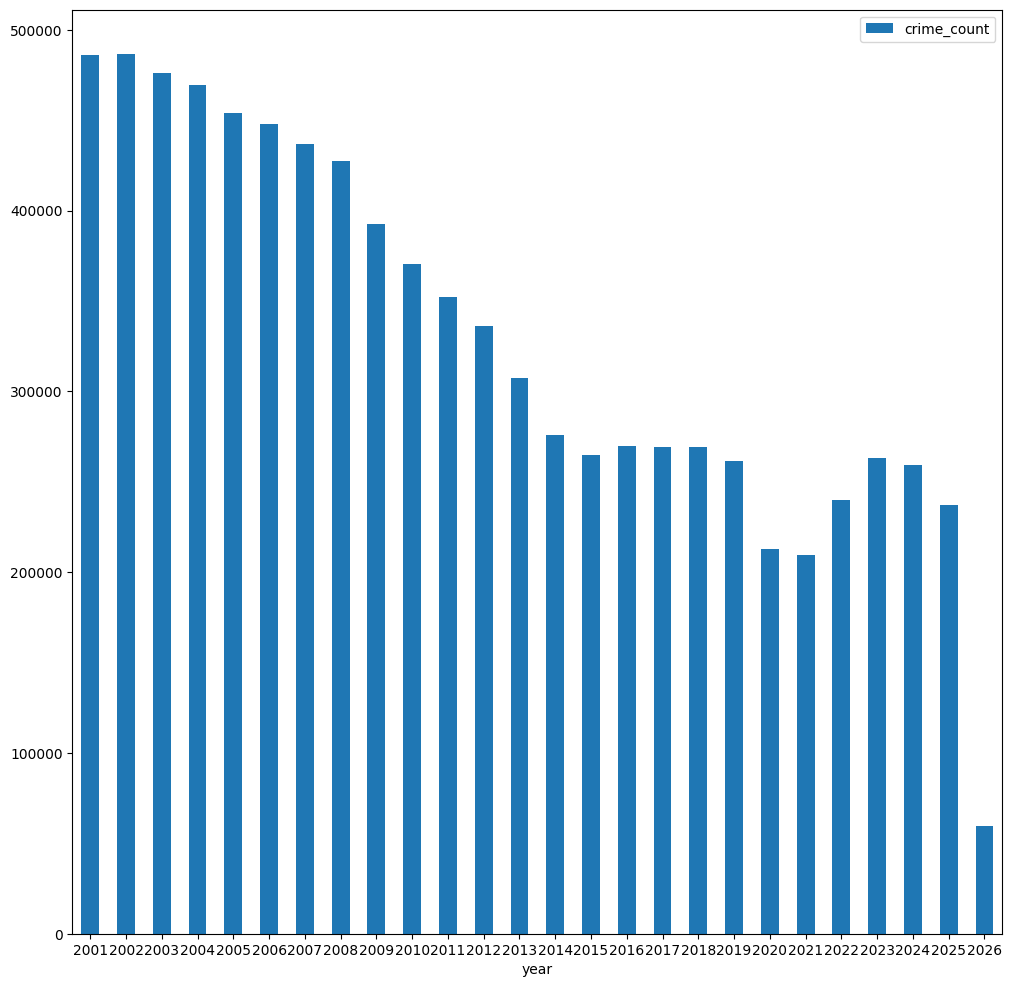

In [33]:
crimesByYearPDF.plot.bar(x='year', y='crime_count', rot=0,figsize=(12, 12))

#### 4.2. Crimes count by day

In [34]:

crimesByDayDF=spark.sql("SELECT case_day_of_week_name as day,count(*) AS crime_count FROM chicago_crimes_temp_view GROUP BY case_day_of_week_name ORDER BY case_day_of_week_name;")
crimesByDayDF.show()

  0%|           0/3 Tasks

+---------+-----------+
|      day|crime_count|
+---------+-----------+
|     NULL|    1224462|
|   Friday|    1226152|
| Saturday|    1214077|
|   Sunday|    1280033|
| Thursday|    1218150|
|  Tuesday|    1165713|
|Wednesday|    1207982|
+---------+-----------+



In [35]:
# Convert results to a Pandas dataframe for visualization
crimesByDayPDF = crimesByDayDF.toPandas()

  0%|           0/3 Tasks

<Axes: title={'center': 'Crimes by day of week'}, ylabel='crime_count'>

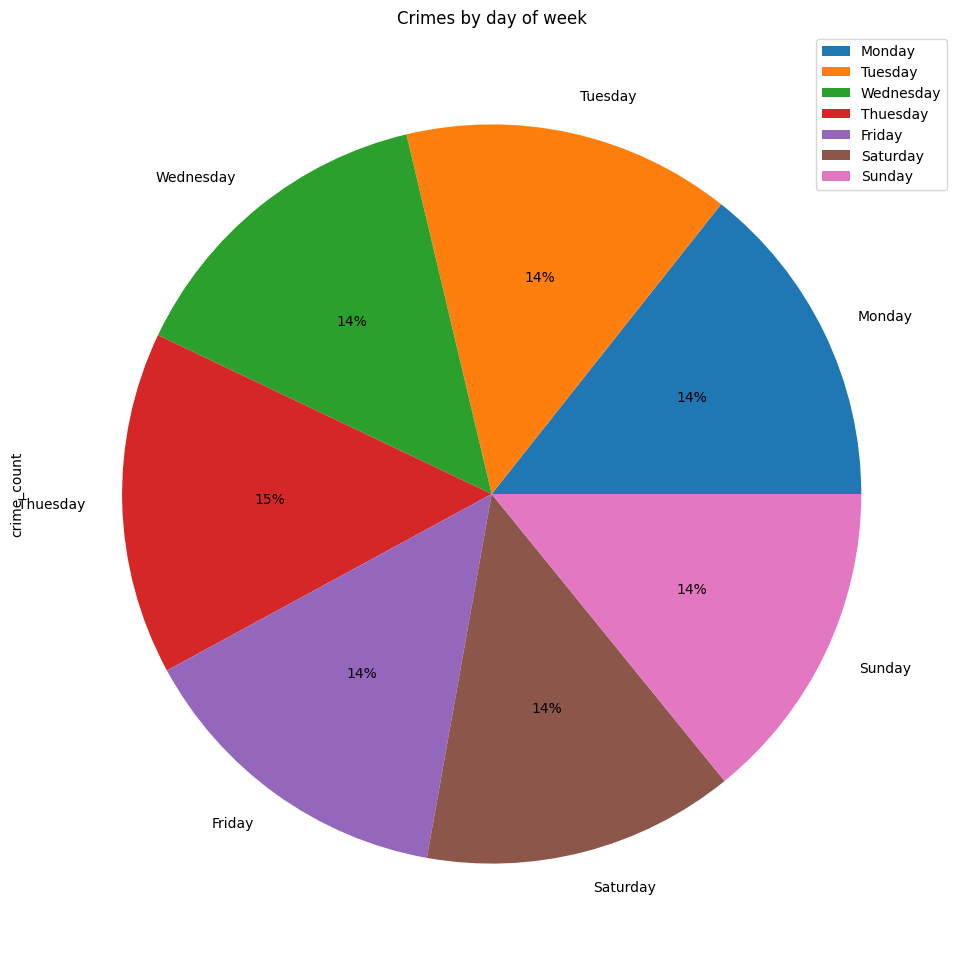

In [36]:
crimesByDayPDF.plot.pie(y='crime_count', x='day', figsize=(12,12),title='Crimes by day of week', labels = ['Monday','Tuesday','Wednesday','Thuesday','Friday','Saturday','Sunday'],autopct='%1.0f%%')